# Data Mining Lab Work

## Name: Pratyush Pravanjan Pradhan
## roll number: 251248
## Labwork

In [99]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Apply K means over 20 random 1-dimension points with k = 3, ask the user to give values of k.

In [100]:
#generating 20 random integers
points=np.random.randint(0,100,20)
print(points)

[63 18 16 99 22 87 26 81 25 22 70 86 29 95  8 72 35 75 54  6]


In [101]:
k=int(input("enter the value of k: "))

enter the value of k: 3


In [102]:
#choosing k number of points as centroids
centroids = np.random.choice(points, k, replace=False)
print("Initial centroids:")
print(centroids)

Initial centroids:
[86 70 16]


In [103]:
#clustering the points towards the centroid and
#iterating until the centroid converge with its successing one
for i in range(100):
  dist=np.abs(np.subtract.outer(points,centroids))
  labels=np.argmin(dist,axis=1)
  new_centroids=np.array([np.mean(points[labels==j]) for j in range(k)])
  if np.all(centroids==new_centroids):
    break
  centroids=new_centroids
print("Final centroids:")
print(centroids)

Final centroids:
[89.6 66.8 20.7]


In [104]:
print("Final clusters:")

for i in range(k):
  print(f"Cluster {i + 1}:",end=" ")
  print(points[labels == i])
  print("Centroid:", centroids[i])

Final clusters:
Cluster 1: [99 87 81 86 95]
Centroid: 89.6
Cluster 2: [63 70 72 75 54]
Centroid: 66.8
Cluster 3: [18 16 22 26 25 22 29  8 35  6]
Centroid: 20.7


### 2. Apply simple K-means algorithm for clustering any dataset. Compare the performance ofclusters by varying the algorithm parameters. For a given set of parameters, plot a line graph depicting MSE obtained after each iteration.

The Euclidean distance between a data point `x` and centroid `c` is:

$$
d(x,c) = \sqrt{\sum_j (x_j-c_j)^2}
$$

The MSE used here is the mean of the squared distances of each point from its assigned centroid:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n} d(x_i,c_i)^2
$$


In [105]:
def kmeans(data, k, max_iter=100):
  data=np.asarray(data,dtype=float)
  idx = np.random.choice(len(data), k, replace=False)
  centroids=data[idx].copy()
  mse_history=[]

  for i in range(100):
    dist = np.linalg.norm(
      data[:, np.newaxis, :] - centroids,
      axis=2
    )
    labels=np.argmin(dist,axis=1)
    new_centroids=np.array([np.mean(data[labels==j],axis=0) for j in range(k)])

    point_dist=np.min(dist,axis=1)
    mse=np.mean(point_dist**2)
    mse_history.append(mse)

    if np.all(centroids==new_centroids):
      break
    centroids=new_centroids
  return centroids,mse_history,labels

In [106]:
# Generate a reproducible 2-D dataset
rng = np.random.default_rng(42)
group1 = rng.normal(loc=[2,8], scale=1.0, size=(30, 2))
group2 = rng.normal(loc=[8,9], scale=1.0, size=(50, 2))
group3 = rng.normal(loc=[2,2], scale=1.0, size=(40, 2))

data = np.vstack([group1, group2, group3])
print("Dataset shape:", data.shape)

Dataset shape: (120, 2)


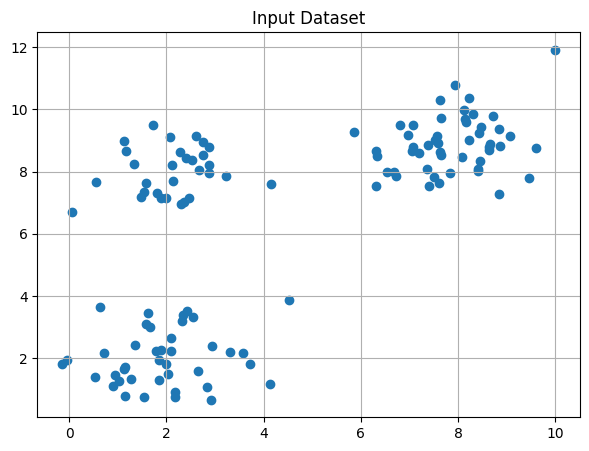

In [107]:
plt.figure(figsize=(7, 5))
plt.scatter(data[:, 0], data[:, 1])
plt.title("Input Dataset")
plt.grid()
plt.show()

In [108]:
k = 3

centroids, mse_history, labels = kmeans(
    data,
    k=k,
    max_iter=100,
)

print("Final centroids:")
print(centroids)

print("\nNumber of iterations:", len(mse_history))
print("Final MSE:", mse_history[-1])

Final centroids:
[[1.92849879 2.03446667]
 [2.12340167 8.00716926]
 [7.83926528 8.88637682]]

Number of iterations: 4
Final MSE: 1.597949089101402


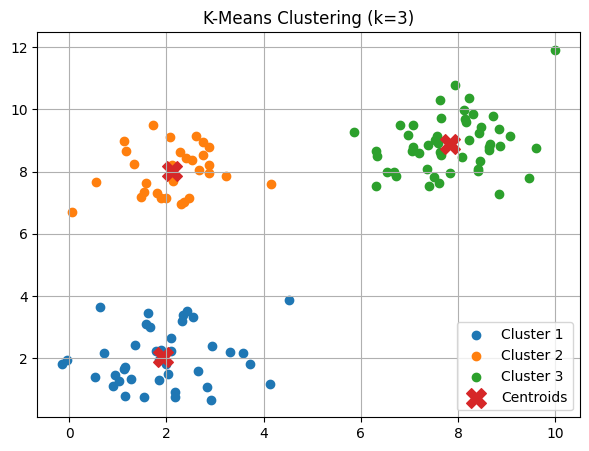

In [109]:
# Visualize the resulting clusters

plt.figure(figsize=(7, 5))

for cluster in range(k):
    cluster_points = data[labels == cluster]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f"Cluster {cluster + 1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering (k=3)")
plt.legend()
plt.grid()
plt.show()

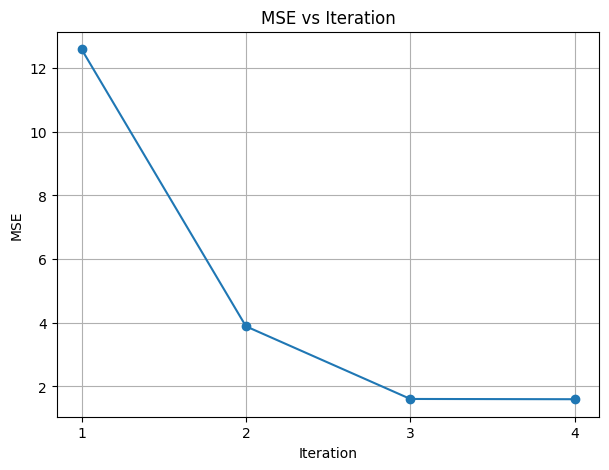

MSE after each iteration:
Iteration 1: 12.5926
Iteration 2: 3.8879
Iteration 3: 1.6061
Iteration 4: 1.5979


In [110]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(mse_history) + 1),
    mse_history,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE vs Iteration")
plt.xticks(range(1, len(mse_history) + 1))
plt.grid()
plt.show()

print("MSE after each iteration:")
for i, mse in enumerate(mse_history, start=1):
    print(f"Iteration {i}: {mse:.4f}")

In [111]:
results = []

for k in [2, 3, 4, 5]:

    centroids_k, mse_history_k,labels_k = kmeans(
        data,
        k=k,
        max_iter=100,
    )

    results.append({
        "k": k,
        "iterations": len(mse_history_k),
        "final_MSE": mse_history_k[-1]
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 k  iterations  final_MSE
 2           3   6.699544
 3          11   1.597949
 4           4   1.386870
 5          10   1.103022


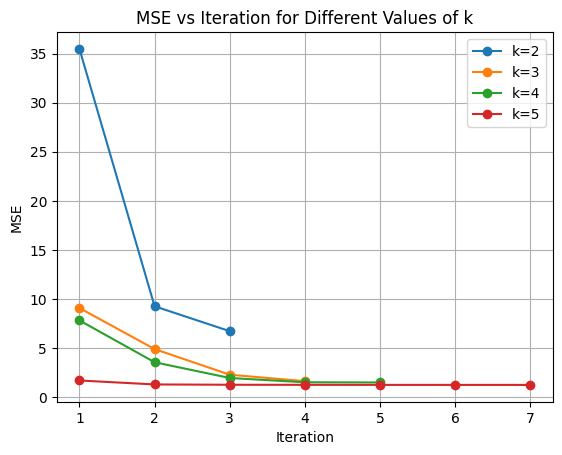

In [112]:
for k in [2, 3, 4, 5]:

    centroids_k, mse_history_k,labels_k  = kmeans(
        data,
        k=k,
        max_iter=100,
    )

    plt.plot(
        range(1, len(mse_history_k) + 1),
        mse_history_k,
        marker="o",
        label=f"k={k}"
    )

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE vs Iteration for Different Values of k")
plt.legend()
plt.grid()
plt.show()